In [8]:
#import libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Global plot style
sns.set_theme(style="whitegrid", palette="Blues_r")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv(r"C:\download\hotel_booking_analytics_dataset.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 6,000 rows × 13 columns


,Booking_ID,Hotel_Type,Booking_Date,Checkin_Date,Checkout_Date,Lead_Time,Country,Adults,Children,Room_Type,ADR,Booking_Channel,Cancellation_Status
0,BKG100000,Resort Hotel,2023-10-17,2023-11-14,2023-11-15,28,Singapore,3,0.0,Standard,124.73,NaN,Check-Out
1,BKG100001,City Hotel,2022-04-06,2022-05-31,2022-06-04,55,NaN,1,2.0,Family,117.66,NaN,Canceled
2,BKG100002,City Hotel,2022-01-07,2022-02-16,2022-02-23,40,USA,3,0.0,Standard,105.09,Offline Agent,Check-Out
3,BKG100003,Resort Hotel,2024-05-17,2024-08-13,2024-08-23,88,Australia,3,0.0,Standard,271.62,Corporate,Canceled
4,BKG100004,Resort Hotel,2023-09-26,2023-12-27,2024-01-06,92,France,2,0.0,Standard,73.29,NaN,Canceled


## Data Explore

In [9]:
# Shape, dtypes, and null counts
print(f"Shape: {df.shape}")
print("\n--- Column Info ---")
df.info()

Shape: (6000, 13)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Booking_ID           6000 non-null   object 
 1   Hotel_Type           6000 non-null   object 
 2   Booking_Date         6000 non-null   object 
 3   Checkin_Date         6000 non-null   object 
 4   Checkout_Date        6000 non-null   object 
 5   Lead_Time            6000 non-null   int64  
 6   Country              5520 non-null   object 
 7   Adults               6000 non-null   int64  
 8   Children             5520 non-null   float64
 9   Room_Type            5520 non-null   object 
 10  ADR                  6000 non-null   float64
 11  Booking_Channel      5520 non-null   object 
 12  Cancellation_Status  6000 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 609.5+ KB


In [10]:
# Descriptive statistics for numeric columns
df.describe().round(2)

,Lead_Time,Adults,Children,ADR
count,6000.00,6000.00,5520.00,6000.00
mean,89.41,2.50,0.59,204.87
std,52.61,1.12,0.79,83.69
min,0.00,1.00,0.00,60.13
25%,43.00,2.00,0.00,132.10
50%,90.00,2.00,0.00,204.63
75%,135.00,4.00,1.00,276.72
max,180.00,4.00,2.00,349.96


In [13]:
# Unique values in categorical columns
cat_cols = ["Hotel_Type", "Room_Type", "Booking_Channel", "Cancellation_Status"]
for col in cat_cols:
    print(f"{col}: {df[col].dropna().unique().tolist()}")

Hotel_Type: ['Resort Hotel', 'City Hotel']
Room_Type: ['Standard', 'Family', 'Suite', 'Deluxe']
Booking_Channel: ['Offline Agent', 'Corporate', 'Direct', 'Online Travel Agent']
Cancellation_Status: ['Check-Out', 'Canceled', 'No-Show']


In [17]:
# Missing values summary
null_summary = df.isnull().sum().reset_index()
null_summary.columns = ["Column", "Missing Count"]
null_summary["Missing %"] = (null_summary["Missing Count"] / len(df) * 100).round(2)
null_summary[null_summary["Missing Count"] > 0]

,Column,Missing Count,Missing %
6,Country,480,8.0
8,Children,480,8.0
9,Room_Type,480,8.0
11,Booking_Channel,480,8.0


##  Data Cleaning

In [18]:
# Children: count column — fill with 0 (most guests have no children), NOT mean
df["Children"] = df["Children"].fillna(0)

In [19]:
# Country, Room_Type, Booking_Channel: fill with mode
for col in ["Country", "Room_Type", "Booking_Channel"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [20]:
# Convert date columns to datetime
for col in ["Booking_Date", "Checkin_Date", "Checkout_Date"]:
    df[col] = pd.to_datetime(df[col])

In [21]:
# Rename ADR for clarity
df.rename(columns={"ADR": "Average_Daily_Rate"}, inplace=True)

In [22]:
# Confirm no nulls remain
print("Nulls after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n✅ No nulls remaining." if df.isnull().sum().sum() == 0 else "⚠️ Some nulls remain.")

Nulls after cleaning:
Series([], dtype: int64)

✅ No nulls remaining.


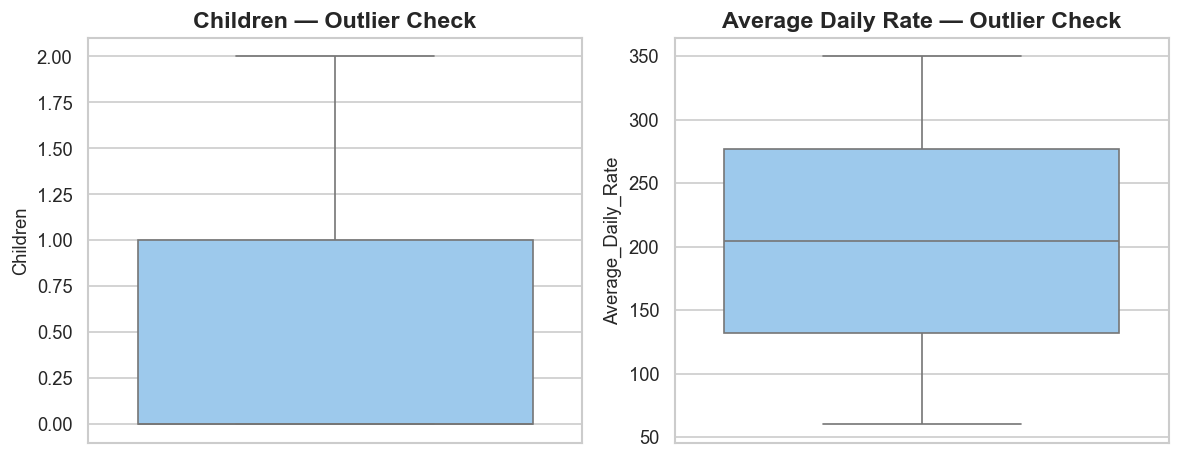

In [23]:
# Outlier check: Children boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["Children"], ax=axes[0], color="#90CAF9")
axes[0].set_title("Children — Outlier Check")
sns.boxplot(y=df["Average_Daily_Rate"], ax=axes[1], color="#90CAF9")
axes[1].set_title("Average Daily Rate — Outlier Check")
plt.tight_layout()
plt.show()

## Feature Engineering

In [25]:
df["year"]       = df["Booking_Date"].dt.year
df["month"]      = df["Booking_Date"].dt.month
df["month_name"] = df["Booking_Date"].dt.strftime("%b")
df["month_year"] = df["Booking_Date"].dt.to_period("M")

# Stay duration and revenue
df["Stay_Duration"] = (df["Checkout_Date"] - df["Checkin_Date"]).dt.days
df["Revenue"]       = df["Average_Daily_Rate"] * df["Stay_Duration"]
# Flag: is_canceled (binary)
df["is_canceled"] = (df["Cancellation_Status"] == "Canceled").astype(int)

In [26]:
# Validate Stay_Duration
zero_stay = df[df["Stay_Duration"] <= 0].shape[0]
print(f"Rows with Stay_Duration ≤ 0: {zero_stay}")

print(f"\nEngineered features added. Dataset now has {df.shape[1]} columns.")
df[["Booking_Date", "Stay_Duration", "Revenue", "is_canceled", "year", "month"]].head()

Rows with Stay_Duration ≤ 0: 0

Engineered features added. Dataset now has 20 columns.


,Booking_Date,Stay_Duration,Revenue,is_canceled,year,month
0,2023-10-17,1,124.73,0,2023,10
1,2022-04-06,4,470.64,1,2022,4
2,2022-01-07,7,735.63,0,2022,1
3,2024-05-17,10,2716.20,1,2024,5
4,2023-09-26,10,732.90,1,2023,9


## Univariate Analysis

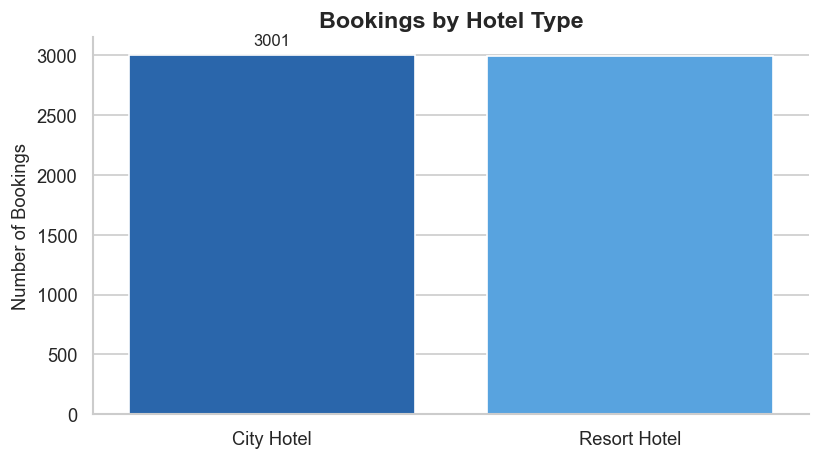

In [29]:
# --- Bookings by Hotel Type ---
hotel_counts = df["Hotel_Type"].value_counts().reset_index()
hotel_counts.columns = ["Hotel_Type", "Bookings"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = sns.barplot(data=hotel_counts, x="Hotel_Type", y="Bookings",
                   palette=["#1565C0", "#42A5F5"], ax=ax)
ax.bar_label(ax.containers[0], fmt="%d", fontsize=10, padding=4)
ax.set_title("Bookings by Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("Number of Bookings")
sns.despine()
plt.tight_layout()
plt.show()

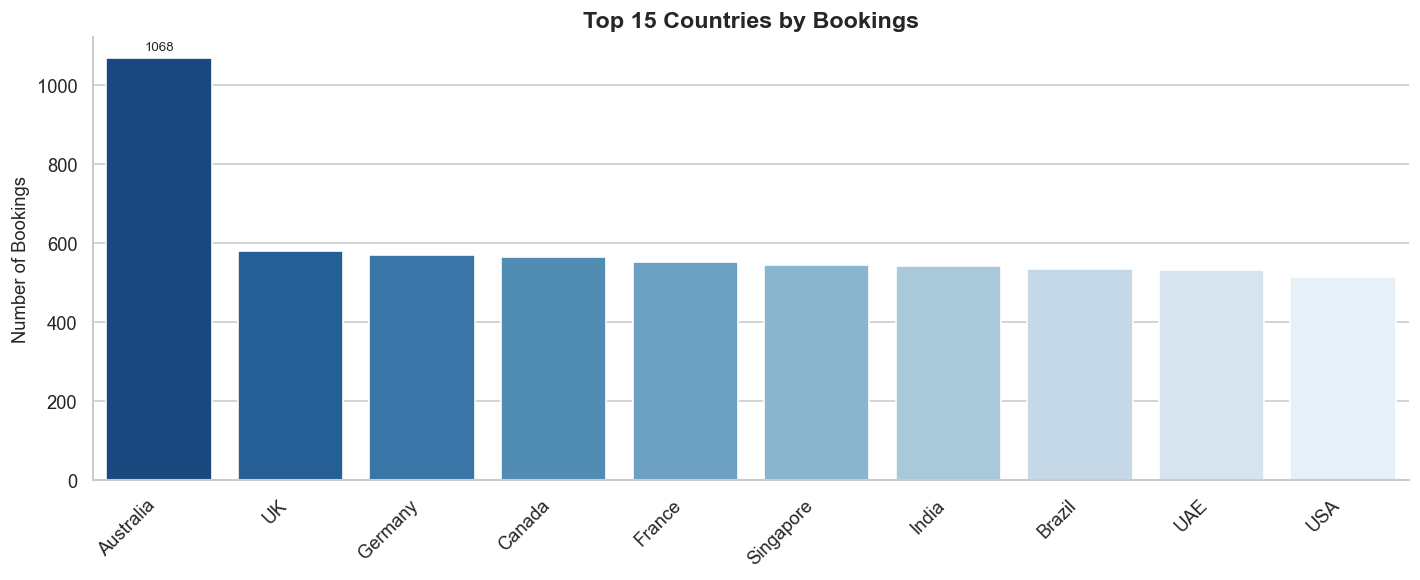

In [30]:
# --- Bookings by Country (Top 15) ---
top_countries = df["Country"].value_counts().reset_index()
top_countries.columns = ["Country", "Bookings"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_countries, x="Country", y="Bookings",
            palette="Blues_r", ax=ax)
ax.bar_label(ax.containers[0], fmt="%d", fontsize=8, padding=3)
ax.set_title("Top 15 Countries by Bookings")
ax.set_xlabel("")
ax.set_ylabel("Number of Bookings")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

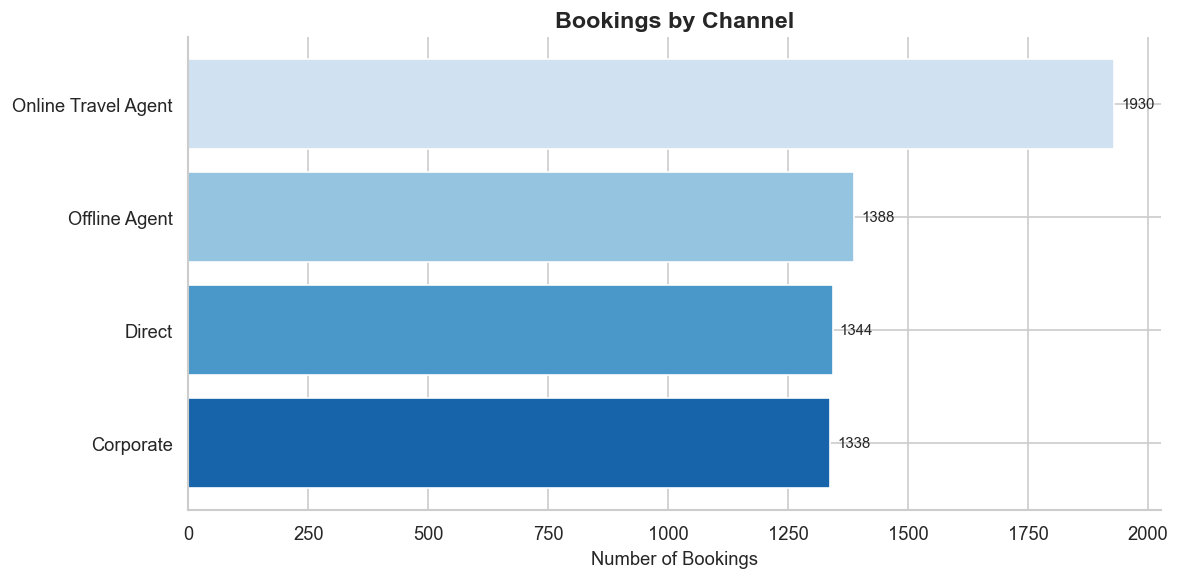

In [31]:
# --- Bookings by Booking Channel (sorted) ---
channel_counts = df["Booking_Channel"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(channel_counts.index, channel_counts.values,
               color=sns.color_palette("Blues_r", len(channel_counts)))
ax.bar_label(bars, fmt="%d", padding=4, fontsize=9)
ax.set_title("Bookings by Channel")
ax.set_xlabel("Number of Bookings")
sns.despine()
plt.tight_layout()
plt.show()

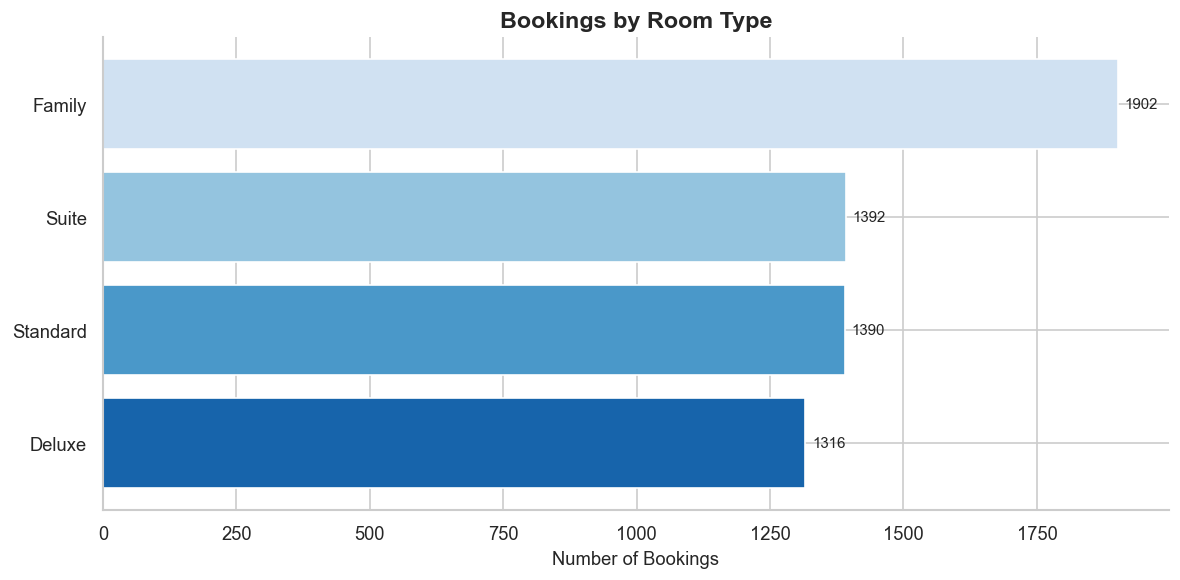

In [32]:
# --- Bookings by Room Type (sorted) ---
room_counts = df["Room_Type"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(room_counts.index, room_counts.values,
               color=sns.color_palette("Blues_r", len(room_counts)))
ax.bar_label(bars, fmt="%d", padding=4, fontsize=9)
ax.set_title("Bookings by Room Type")
ax.set_xlabel("Number of Bookings")
sns.despine()
plt.tight_layout()
plt.show()

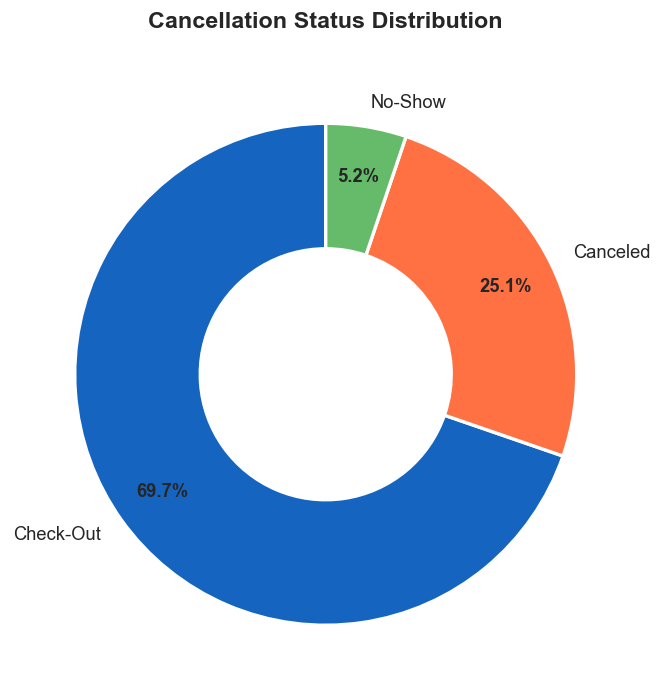

Cancellation_Status
Check-Out    4183
Canceled     1506
No-Show       311


In [33]:
# --- Cancellation Distribution (Donut Chart) ---
cancel_counts = df["Cancellation_Status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#1565C0", "#FF7043", "#66BB6A"]
wedges, texts, autotexts = ax.pie(
    cancel_counts.values,
    labels=cancel_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.80,
    colors=colors[:len(cancel_counts)],
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax.set_title("Cancellation Status Distribution", pad=20)
plt.tight_layout()
plt.show()

print(cancel_counts.to_string())

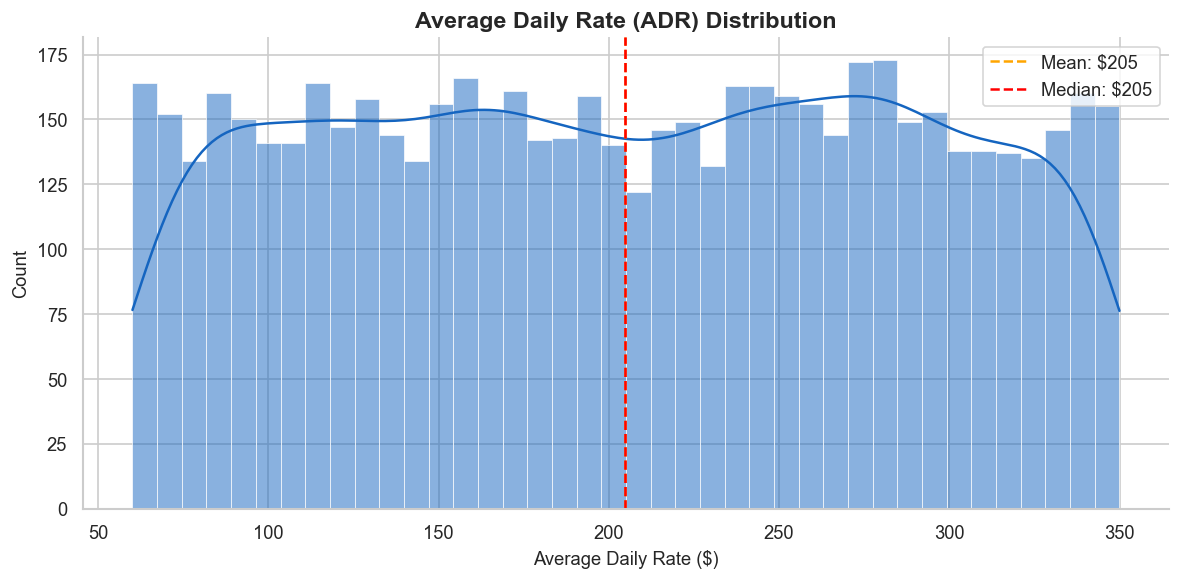

In [34]:
# --- ADR Distribution ---
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Average_Daily_Rate"], bins=40, kde=True,
             color="#1565C0", edgecolor="white", linewidth=0.4, ax=ax)
ax.axvline(df["Average_Daily_Rate"].mean(), color="orange",
           linestyle="--", linewidth=1.5,
           label=f'Mean: ${df["Average_Daily_Rate"].mean():.0f}')
ax.axvline(df["Average_Daily_Rate"].median(), color="red",
           linestyle="--", linewidth=1.5,
           label=f'Median: ${df["Average_Daily_Rate"].median():.0f}')
ax.set_title("Average Daily Rate (ADR) Distribution")
ax.set_xlabel("Average Daily Rate ($)")
ax.set_ylabel("Count")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

Average Stay Duration: 5.54 days
Most Common Stay (mode): 5 days


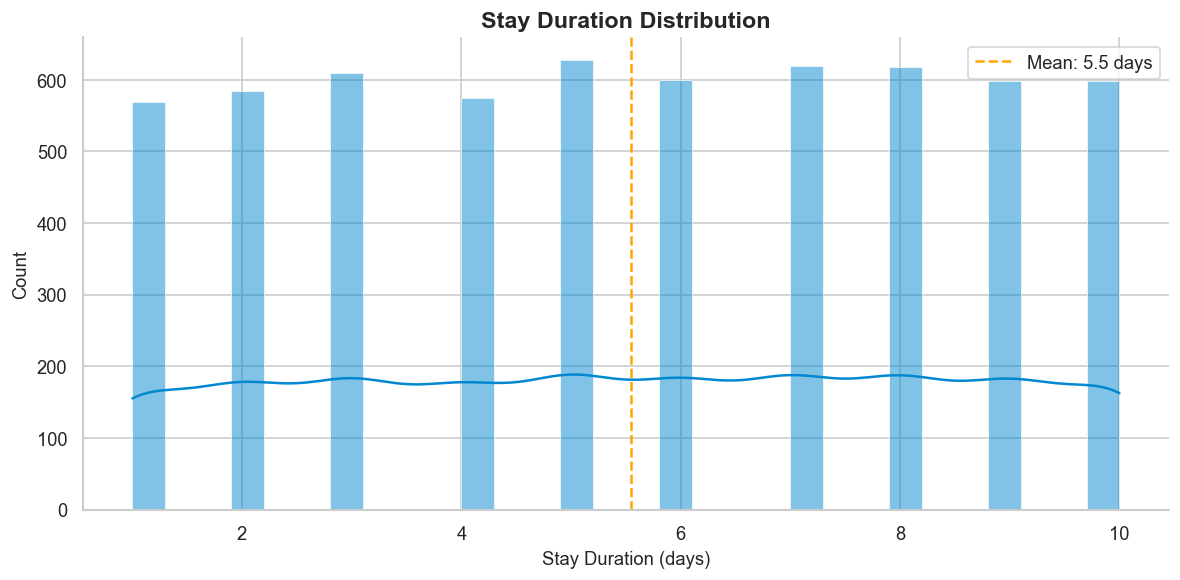

In [35]:
# --- Stay Duration Distribution ---
avg_stay = df["Stay_Duration"].mean()
print(f"Average Stay Duration: {avg_stay:.2f} days")
print(f"Most Common Stay (mode): {int(df['Stay_Duration'].mode()[0])} days")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Stay_Duration"], bins=30, kde=True,
             color="#0288D1", edgecolor="white", linewidth=0.4, ax=ax)
ax.axvline(avg_stay, color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean: {avg_stay:.1f} days")
ax.set_title("Stay Duration Distribution")
ax.set_xlabel("Stay Duration (days)")
ax.set_ylabel("Count")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Bivariate & Revenue Analysis

In [36]:
# --- Average Daily Rate by Room Type & Hotel Type (Pivot Table) ---
roomtype_adr = df.pivot_table(
    values="Average_Daily_Rate",
    columns="Room_Type",
    index="Hotel_Type",
    aggfunc="mean",      # pass string, not np.mean — avoids FutureWarning
    margins=True
).round(2)

print("Average Daily Rate by Hotel Type & Room Type ($):")
roomtype_adr

Average Daily Rate by Hotel Type & Room Type ($):


Room_Type,Deluxe,Family,Standard,Suite,All
Hotel_Type,,,,,
City Hotel,202.17,200.72,209.01,208.84,204.78
Resort Hotel,210.56,206.11,203.78,199.45,204.96
All,206.32,203.37,206.34,204.09,204.87


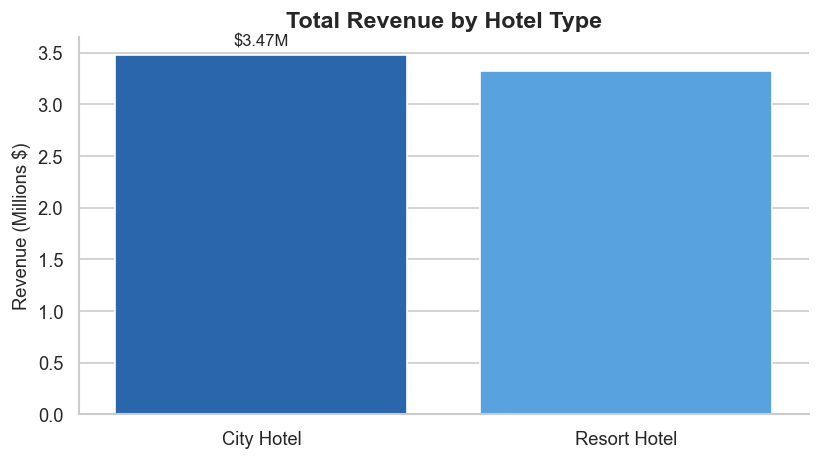

In [37]:
# --- Revenue by Hotel Type ---
hotel_revenue = df.groupby("Hotel_Type")["Revenue"].sum().reset_index()
hotel_revenue.columns = ["Hotel_Type", "Total_Revenue"]
hotel_revenue["Revenue_M"] = hotel_revenue["Total_Revenue"] / 1e6

fig, ax = plt.subplots(figsize=(7, 4))
bars = sns.barplot(data=hotel_revenue, x="Hotel_Type", y="Revenue_M",
                   palette=["#1565C0", "#42A5F5"], ax=ax)
ax.bar_label(ax.containers[0], fmt="$%.2fM", fontsize=10, padding=4)
ax.set_title("Total Revenue by Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("Revenue (Millions $)")
sns.despine()
plt.tight_layout()
plt.show()

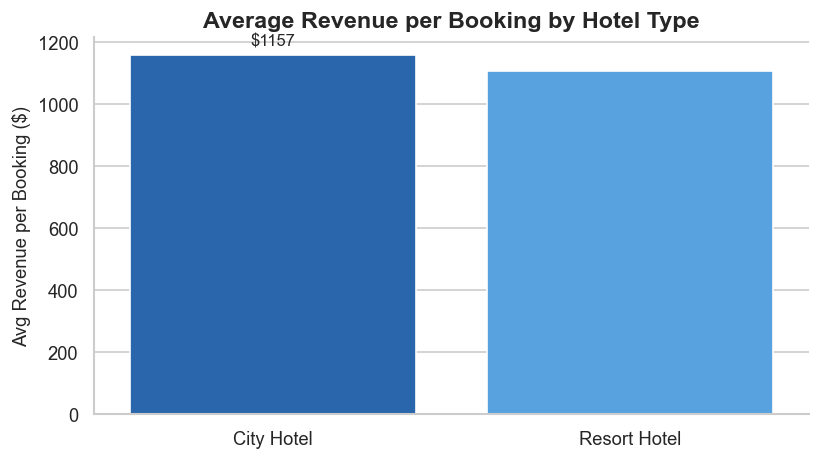

In [38]:
# --- Average Revenue per Booking by Hotel Type (fairer comparison) ---
avg_rev = df.groupby("Hotel_Type")["Revenue"].mean().reset_index()
avg_rev.columns = ["Hotel_Type", "Avg_Revenue_per_Booking"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=avg_rev, x="Hotel_Type", y="Avg_Revenue_per_Booking",
            palette=["#1565C0", "#42A5F5"], ax=ax)
ax.bar_label(ax.containers[0], fmt="$%.0f", fontsize=10, padding=4)
ax.set_title("Average Revenue per Booking by Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("Avg Revenue per Booking ($)")
sns.despine()
plt.tight_layout()
plt.show()

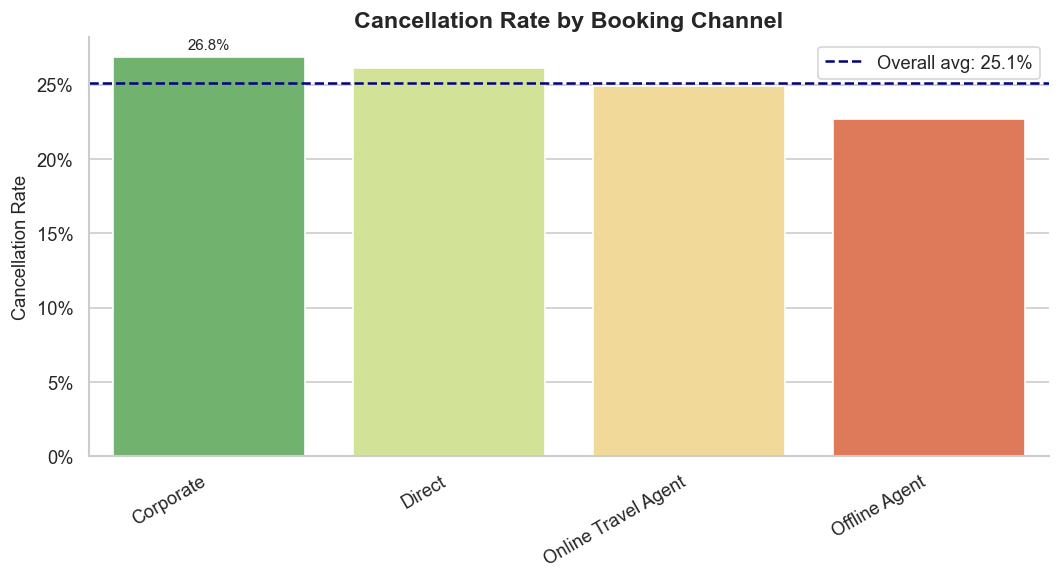

In [39]:
# --- Cancellation Rate by Booking Channel ---
cancel_rate = (
    df.groupby("Booking_Channel")["is_canceled"].mean() * 100
).sort_values(ascending=False).reset_index()
cancel_rate.columns = ["Booking_Channel", "Cancellation_Rate"]

overall_rate = df["is_canceled"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = sns.barplot(data=cancel_rate, x="Booking_Channel", y="Cancellation_Rate",
                   palette="RdYlGn_r", ax=ax)
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=9, padding=3)
ax.axhline(overall_rate, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall avg: {overall_rate:.1f}%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title("Cancellation Rate by Booking Channel")
ax.set_xlabel("")
ax.set_ylabel("Cancellation Rate")
ax.legend()
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

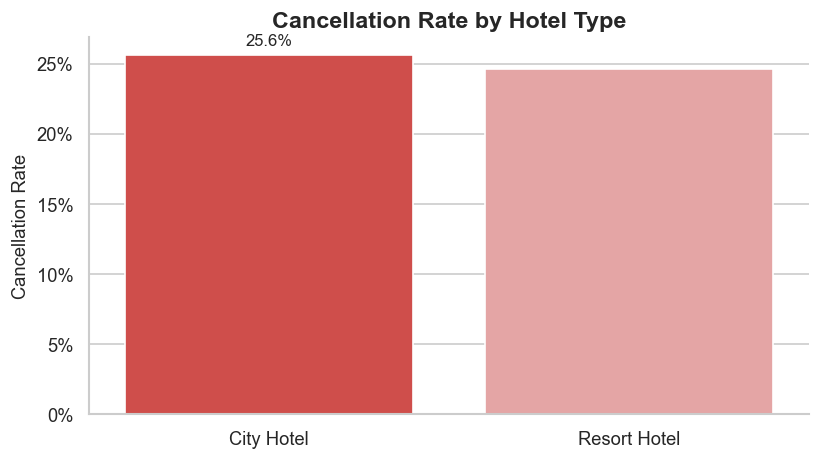

In [40]:
# --- Cancellation Rate by Hotel Type ---
cancel_hotel = (
    df.groupby("Hotel_Type")["is_canceled"].mean() * 100
).reset_index()
cancel_hotel.columns = ["Hotel_Type", "Cancellation_Rate"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=cancel_hotel, x="Hotel_Type", y="Cancellation_Rate",
            palette=["#E53935", "#EF9A9A"], ax=ax)
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=10, padding=4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title("Cancellation Rate by Hotel Type")
ax.set_xlabel("")
ax.set_ylabel("Cancellation Rate")
sns.despine()
plt.tight_layout()
plt.show()

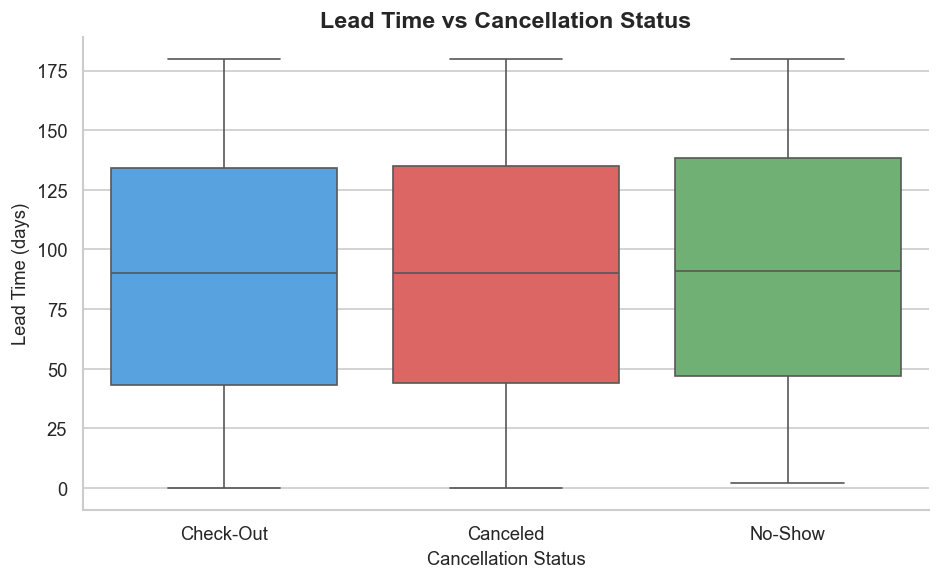

                      count  mean   std  min   25%   50%    75%    max
Cancellation_Status                                                   
Canceled             1506.0  90.0  52.0  0.0  44.0  90.0  135.0  180.0
Check-Out            4183.0  89.0  52.9  0.0  43.0  90.0  134.0  180.0
No-Show               311.0  92.2  52.3  2.0  47.0  91.0  138.5  180.0


In [41]:
# --- Lead Time vs Cancellation (Boxplot) ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Cancellation_Status", y="Lead_Time", data=df,
            palette=["#42A5F5", "#EF5350", "#66BB6A"], ax=ax)
ax.set_title("Lead Time vs Cancellation Status")
ax.set_xlabel("Cancellation Status")
ax.set_ylabel("Lead Time (days)")
sns.despine()
plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby("Cancellation_Status")["Lead_Time"].describe().round(1))

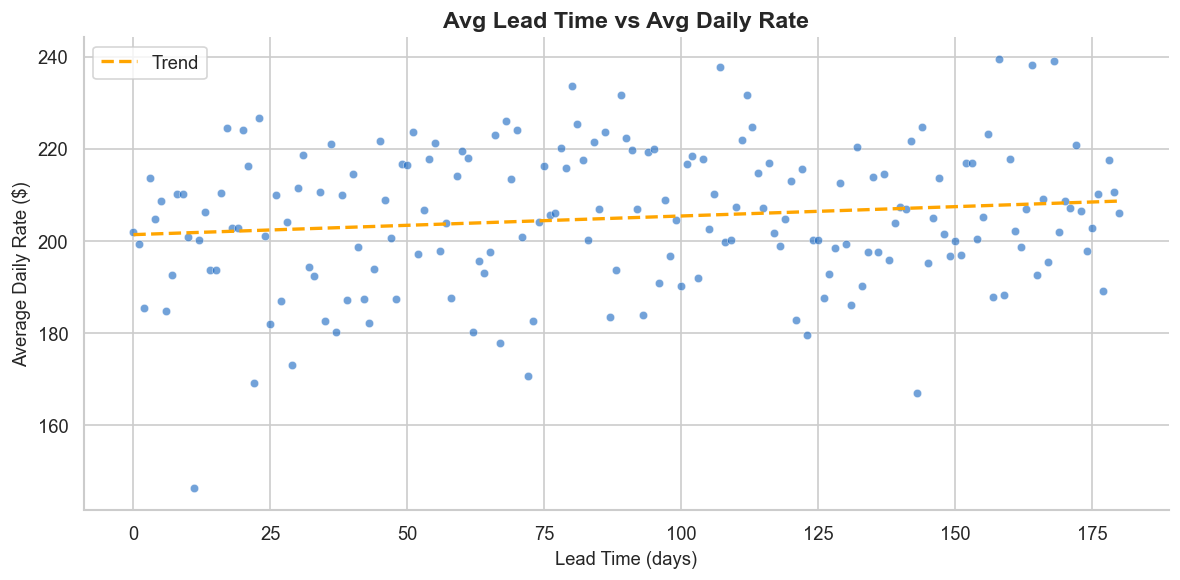

In [42]:
# --- Average Lead Time vs Average ADR (Scatter) ---
avg_data = df.groupby("Lead_Time", as_index=False)["Average_Daily_Rate"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x="Lead_Time", y="Average_Daily_Rate", data=avg_data,
                color="#1565C0", alpha=0.6, s=25, ax=ax)
# Trend line
z = np.polyfit(avg_data["Lead_Time"], avg_data["Average_Daily_Rate"], 1)
p = np.poly1d(z)
ax.plot(sorted(avg_data["Lead_Time"]), p(sorted(avg_data["Lead_Time"])),
        color="orange", linewidth=2, linestyle="--", label="Trend")
ax.set_title("Avg Lead Time vs Avg Daily Rate")
ax.set_xlabel("Lead Time (days)")
ax.set_ylabel("Average Daily Rate ($)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Time Series & Seasonal Analysis

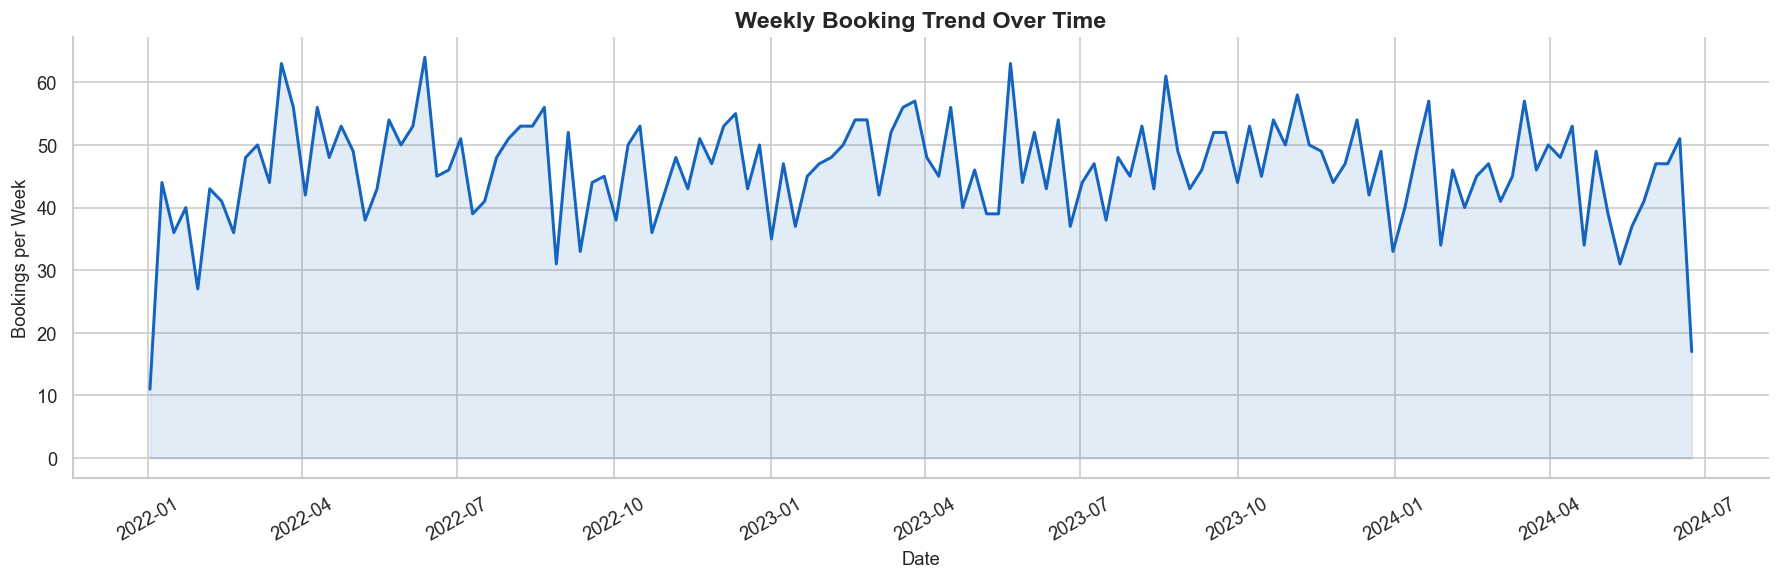

In [44]:
# --- Weekly Booking Trend (smoother than daily) ---
booking_trend = df.set_index("Booking_Date").resample("W")["Booking_ID"].count()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(booking_trend.index, booking_trend.values, color="#1565C0", linewidth=1.8)
ax.fill_between(booking_trend.index, booking_trend.values,
                alpha=0.12, color="#1565C0")
ax.set_title("Weekly Booking Trend Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Bookings per Week")
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

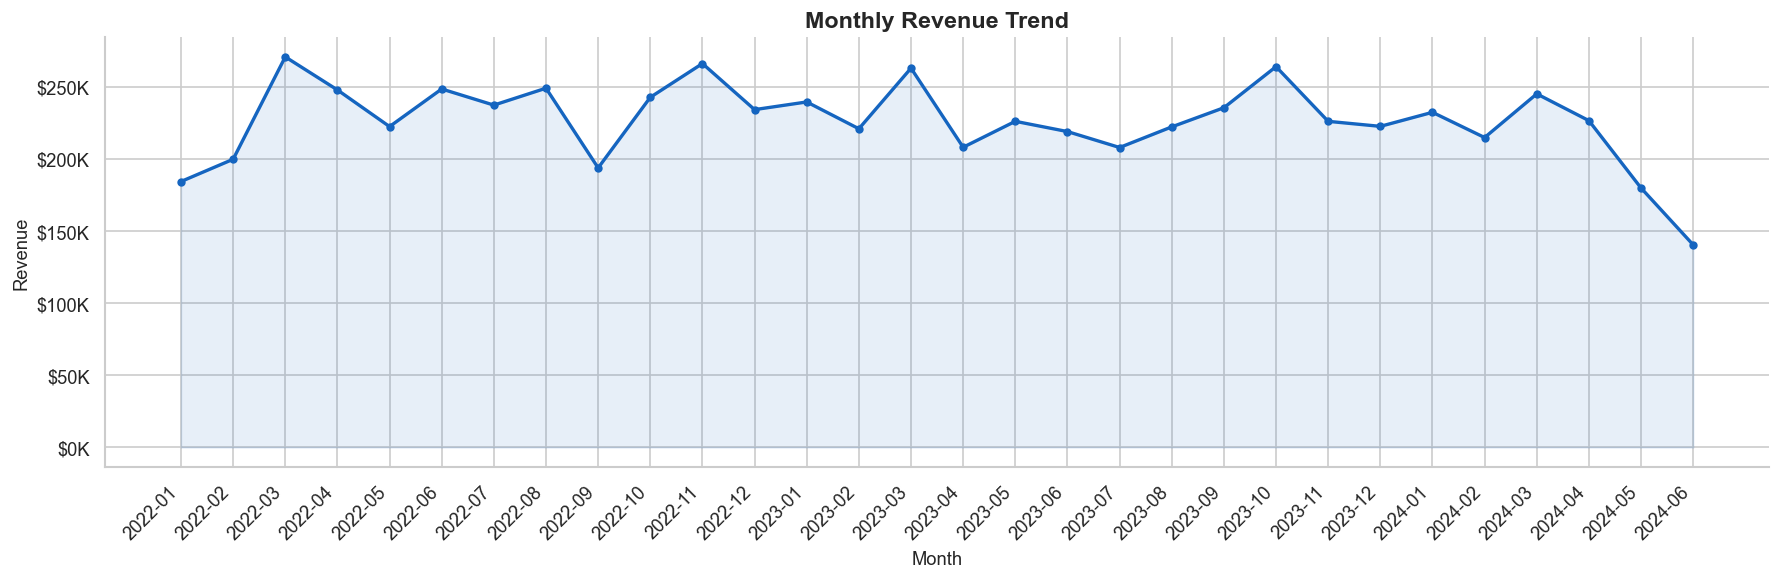

In [45]:
# --- Monthly Revenue Trend ---
monthly_revenue = df.groupby("month_year")["Revenue"].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values,
        color="#1565C0", linewidth=2, marker="o", markersize=4)
ax.fill_between(monthly_revenue.index, monthly_revenue.values,
                alpha=0.1, color="#1565C0")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

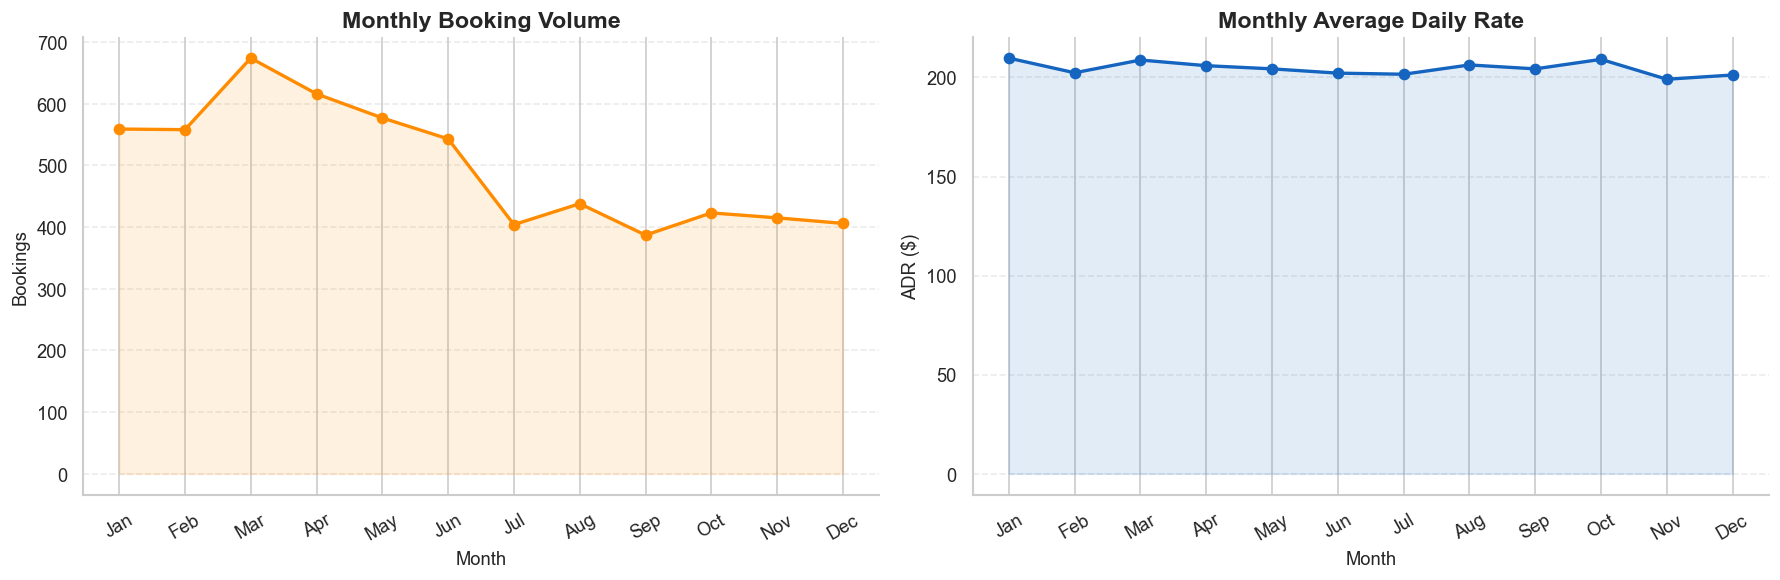

In [46]:
# --- Month-wise Bookings & ADR (side by side) ---
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_bookings = df.groupby("month_name")["Booking_ID"].count().reindex(month_order)
monthly_adr      = df.groupby("month_name")["Average_Daily_Rate"].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bookings
axes[0].plot(monthly_bookings.index, monthly_bookings.values,
             color="darkorange", marker="o", linewidth=2)
axes[0].fill_between(monthly_bookings.index, monthly_bookings.values,
                     alpha=0.12, color="darkorange")
axes[0].set_title("Monthly Booking Volume")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Bookings")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# ADR
axes[1].plot(monthly_adr.index, monthly_adr.values,
             color="#1565C0", marker="o", linewidth=2)
axes[1].fill_between(monthly_adr.index, monthly_adr.values,
                     alpha=0.12, color="#1565C0")
axes[1].set_title("Monthly Average Daily Rate")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("ADR ($)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

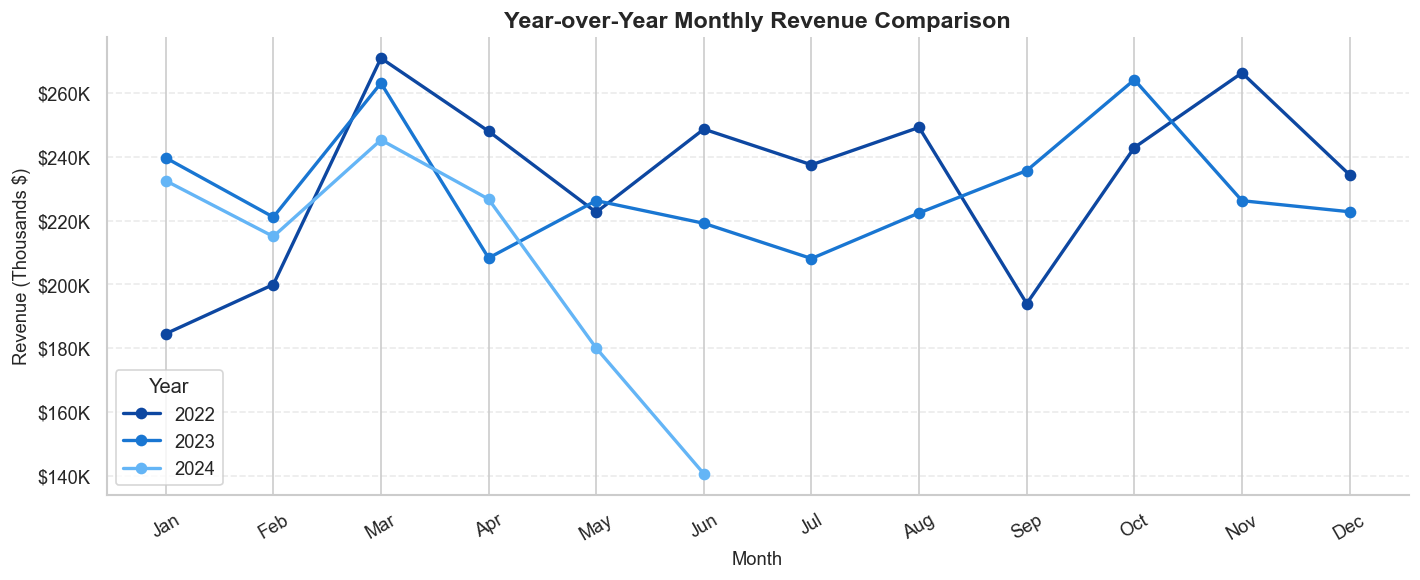

In [47]:
# --- Year-over-Year Monthly Revenue Comparison ---
yoy = df.groupby(["year", "month"])["Revenue"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
colors_yoy = ["#0D47A1", "#1976D2", "#64B5F6"]
for i, yr in enumerate(sorted(yoy["year"].unique())):
    subset = yoy[yoy["year"] == yr]
    ax.plot(subset["month"], subset["Revenue"] / 1e3,
            marker="o", linewidth=2, label=str(yr), color=colors_yoy[i % len(colors_yoy)])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.set_title("Year-over-Year Monthly Revenue Comparison")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (Thousands $)")
ax.legend(title="Year")
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

##  Correlation Analysis

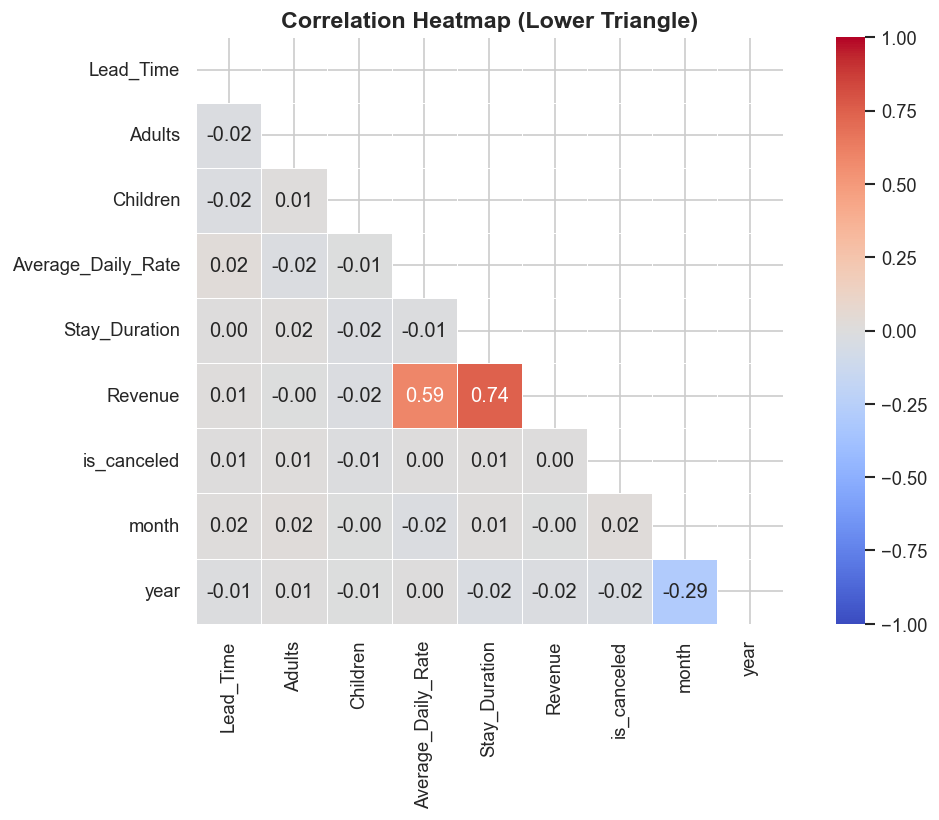

In [48]:
# --- Correlation Heatmap ---
numeric_cols = ["Lead_Time", "Adults", "Children", "Average_Daily_Rate",
                "Stay_Duration", "Revenue", "is_canceled", "month", "year"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, square=True, linewidths=0.5,
            vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

In [49]:
# --- Compute key stats for the business story ---
top_hotel     = hotel_revenue.sort_values("Total_Revenue", ascending=False).iloc[0]["Hotel_Type"]
top_hotel_pct = (hotel_revenue.sort_values("Total_Revenue", ascending=False).iloc[0]["Total_Revenue"]
                 / hotel_revenue["Total_Revenue"].sum() * 100)

highest_cancel_channel = cancel_rate.iloc[0]["Booking_Channel"]
highest_cancel_rate    = cancel_rate.iloc[0]["Cancellation_Rate"]
lowest_cancel_channel  = cancel_rate.iloc[-1]["Booking_Channel"]
lowest_cancel_rate     = cancel_rate.iloc[-1]["Cancellation_Rate"]

canceled_lead   = df[df["Cancellation_Status"] == "Canceled"]["Lead_Time"].median()
checkedout_lead = df[df["Cancellation_Status"] == "Check-Out"]["Lead_Time"].median()

overall_cancel_rate = df["is_canceled"].mean() * 100
top_country         = df["Country"].value_counts().index[0]

city_adr   = df[df["Hotel_Type"] == "City Hotel"]["Average_Daily_Rate"].mean()
resort_adr = df[df["Hotel_Type"] == "Resort Hotel"]["Average_Daily_Rate"].mean()

print(f"""
Key Stats Summary
═══════════════════════════════════════════════════════════════
  Total bookings       : {len(df):,}
  Overall cancel rate  : {overall_cancel_rate:.1f}%
  Top revenue hotel    : {top_hotel} ({top_hotel_pct:.1f}% of total revenue)
  Highest cancel chan. : {highest_cancel_channel} ({highest_cancel_rate:.1f}%)
  Lowest cancel chan.  : {lowest_cancel_channel} ({lowest_cancel_rate:.1f}%)
  Median lead (cancel) : {canceled_lead:.0f} days
  Median lead (stayed) : {checkedout_lead:.0f} days
  Avg stay duration    : {df['Stay_Duration'].mean():.1f} days
  Top booking country  : {top_country}
  City Hotel avg ADR   : ${city_adr:.2f}
  Resort Hotel avg ADR : ${resort_adr:.2f}
═══════════════════════════════════════════════════════════════
""")


Key Stats Summary
═══════════════════════════════════════════════════════════════
  Total bookings       : 6,000
  Overall cancel rate  : 25.1%
  Top revenue hotel    : City Hotel (51.1% of total revenue)
  Highest cancel chan. : Corporate (26.8%)
  Lowest cancel chan.  : Offline Agent (22.7%)
  Median lead (cancel) : 90 days
  Median lead (stayed) : 90 days
  Avg stay duration    : 5.5 days
  Top booking country  : Australia
  City Hotel avg ADR   : $204.78
  Resort Hotel avg ADR : $204.96
═══════════════════════════════════════════════════════════════



In [50]:
# --- Final Business Story ---
print(f"""
═══════════════════════════════════════════════════════════════
                        BUSINESS STORY
═══════════════════════════════════════════════════════════════

1. CANCELLATION RISK VARIES BY BOOKING CHANNEL
   Overall cancellation rate is {overall_cancel_rate:.1f}% across 6,000 bookings.
   {highest_cancel_channel} records the highest cancellation rate at
   {highest_cancel_rate:.1f}%, while {lowest_cancel_channel} has the lowest at
   {lowest_cancel_rate:.1f}% — a gap that represents a direct revenue leakage
   opportunity.

2. HOTEL REVENUE IS CONCENTRATED BUT ADR IS NEARLY EQUAL
   {top_hotel} contributes {top_hotel_pct:.1f}% of total revenue. However,
   average daily rates are almost identical across both hotel types
   (City: ${city_adr:.0f} vs Resort: ${resort_adr:.0f}), meaning the revenue
   gap is driven by booking volume, not pricing power.

3. SHORT STAYS DOMINATE — BUT STAY LENGTH IS NOT LINKED TO CANCELLATION
   Average stay is {df['Stay_Duration'].mean():.1f} days (mode: 5 days), confirming
   demand is short-term in nature. Notably, median lead time is
   nearly identical for canceled ({canceled_lead:.0f} days) and checked-out
   ({checkedout_lead:.0f} days) guests, meaning lead time alone is NOT a
   reliable predictor of cancellation in this dataset.

4. A FEW KEY COUNTRIES DRIVE THE MAJORITY OF BOOKINGS
   {top_country} is the top source market. Demand is geographically
   concentrated, making it efficient to focus retention and
   acquisition efforts on a small number of high-value markets.

5. SEASONAL REVENUE PATTERNS ARE CONSISTENT YEAR-OVER-YEAR
   Monthly revenue and ADR show repeating seasonal cycles across
   2022–2024, creating a clear basis for demand-based dynamic
   pricing and inventory planning.

═══════════════════════════════════════════════════════════════
                  FINAL BUSINESS RECOMMENDATION
═══════════════════════════════════════════════════════════════

  → Shift bookings toward {lowest_cancel_channel} (lowest cancel rate)
    through targeted incentives or exclusive direct rates.
  → Address {highest_cancel_channel} cancellations with non-refundable
    deposit options or tighter cancellation windows.
  → Since ADR is equal across hotel types, grow Resort Hotel
    booking volume to reduce revenue concentration risk.
  → Apply dynamic pricing during peak seasonal months to
    capture demand already evidenced in the YoY revenue trend.
  → Focus marketing spend on top source countries where
    conversion is already proven.

═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
                        BUSINESS STORY
═══════════════════════════════════════════════════════════════

1. CANCELLATION RISK VARIES BY BOOKING CHANNEL
   Overall cancellation rate is 25.1% across 6,000 bookings.
   Corporate records the highest cancellation rate at
   26.8%, while Offline Agent has the lowest at
   22.7% — a gap that represents a direct revenue leakage
   opportunity.

2. HOTEL REVENUE IS CONCENTRATED BUT ADR IS NEARLY EQUAL
   City Hotel contributes 51.1% of total revenue. However,
   average daily rates are almost identical across both hotel types
   (City: $205 vs Resort: $205), meaning the revenue
   gap is driven by booking volume, not pricing power.

3. SHORT STAYS DOMINATE — BUT STAY LENGTH IS NOT LINKED TO CANCELLATION
   Average stay is 5.5 days (mode: 5 days), confirming
   demand is short-term in nature. Notably, median lead time is
   nearly identical for canceled (90 days) and checked-out
   